# Personal Portfolio Backtesting Engine

**What this notebook does:** simulates how a real portfolio (NVDA, AMZN, AVGO, XOM, PG) would have
performed historically, benchmarks it against the S&P 500 (SPY), and quantifies its risk-adjusted
performance using the same core metrics used in professional investment research.

**One-sentence resume bullet:** *Built and backtested a quantitative model analyzing a personal stock
portfolio's risk-adjusted returns against the S&P 500, including Monte Carlo risk simulation and
sector/factor analysis; published on GitHub.*


## My Takeaways

- CAGR (46.28%): historically, a portfolio built this way grew about 46% per year on average.
- Sharpe Ratio (1.45): strong return for the risk taken (above 1 is considered good).
- Max Drawdown (-25.87%): at its worst point, this portfolio would have dropped about 26% before recovering.
- Beta (1.37): about 37% more volatile than the overall market — bigger swings both up and down, mainly from the heavier NVDA/AVGO weighting.
- Alpha (11.49%): even after accounting for that extra risk, this beat the market by about 11.5% a year.

Note: this backtest reflects historical performance (Aug 2023–Aug 2026), not a prediction. I invested real money into this same allocation starting [Monday's date], and will track how it actually performs going forward.

## Why I picked these weights
I put more into NVDA (26.7%) and AVGO (21.9%) for AI/chip demand upside, kept AMZN steady at 23.8% for reliable growth, and used XOM (15.7%) and PG (11.9%) as defensive stocks to offset tech risk.

## Setup: install & import packages

In [ ]:
!pip install yfinance tabulate -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from tabulate import tabulate

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
TRADING_DAYS = 252
np.random.seed(42)


## Custom Portfolio Inputs
Edit anything in this cell to change the entire analysis — nothing else in the notebook needs to change.

In [ ]:
# =========================================================
# CUSTOM PORTFOLIO INPUTS — edit this cell only
# =========================================================

TICKERS = ["NVDA", "AMZN", "AVGO", "XOM", "PG"]     # your portfolio (5 stocks)
BENCHMARK = "SPY"                                     # what you're comparing against

START_DATE = "2023-08-17"
END_DATE = "2026-08-17"

INITIAL_INVESTMENT = 1050                             # dollars

WEIGHTING_METHOD = "Custom Weights"
CUSTOM_WEIGHTS = {"NVDA": 0.267, "AMZN": 0.238, "AVGO": 0.219, "XOM": 0.157, "PG": 0.119}

REBALANCE_FREQ = "Quarterly"                          # "None" | "Monthly" | "Quarterly" | "Yearly"

RISK_FREE_RATE = 0.04                                 # annualized, e.g. 0.04 = 4%
TRANSACTION_COST_BPS = 5                              # basis points charged per rebalance trade (5 = 0.05%)

print("Inputs loaded:")
print(f"  Tickers: {TICKERS}")
print(f"  Benchmark: {BENCHMARK}")
print(f"  Period: {START_DATE} to {END_DATE}")
print(f"  Initial investment: ${INITIAL_INVESTMENT:,}")


Inputs loaded:
  Tickers: ['NVDA', 'AMZN', 'AVGO', 'XOM', 'PG']
  Benchmark: SPY
  Period: 2023-08-17 to 2026-08-17
  Initial investment: $1,050


## Data Collection

In [ ]:
def download_data(tickers, benchmark, start, end):
    """Downloads adjusted close prices + volume for all tickers and the benchmark.
    Handles missing data by forward-filling gaps (e.g. holidays across exchanges)."""
    all_tickers = list(dict.fromkeys(tickers + [benchmark]))
    raw = yf.download(all_tickers, start=start, end=end, auto_adjust=True, progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw['Close'].copy()
        volumes = raw['Volume'].copy()
    else:
        prices = raw[['Close']].copy()
        prices.columns = all_tickers
        volumes = raw[['Volume']].copy()
        volumes.columns = all_tickers

    prices = prices.ffill().dropna(how='all')
    missing = [t for t in all_tickers if t not in prices.columns or prices[t].isna().all()]
    if missing:
        print(f"WARNING: no data returned for {missing}. Double-check these tickers are correct.")
    return prices, volumes

prices, volumes = download_data(TICKERS, BENCHMARK, START_DATE, END_DATE)
print(f"Downloaded {prices.shape[0]} trading days for {list(prices.columns)}")
prices.tail()


Downloaded 751 trading days for ['AMZN', 'AVGO', 'NVDA', 'PG', 'SPY', 'XOM']


Ticker,AMZN,AVGO,NVDA,PG,SPY,XOM
Date,,,,,,
2026-08-10,278.089996,422.399994,217.550003,146.440002,773.030029,158.761993
2026-08-11,272.269989,416.079987,217.500000,145.210007,770.559998,158.771927
2026-08-12,267.279999,416.049988,224.089996,144.080002,772.489990,158.722244
2026-08-13,265.130005,417.820007,225.300003,144.259995,777.880005,157.589584
2026-08-14,262.649994,392.989990,225.160004,144.550003,776.340027,159.070007


## Portfolio Construction

In [ ]:
def get_weights(tickers, method, custom_weights=None):
    n = len(tickers)
    if method == "Equal Weight":
        w = {t: 1 / n for t in tickers}
    elif method == "Market Cap Weight":
        mcaps = {}
        for t in tickers:
            try:
                mcaps[t] = yf.Ticker(t).info.get('marketCap', np.nan)
            except Exception:
                mcaps[t] = np.nan
        s = pd.Series(mcaps, dtype=float)
        s = s.fillna(s.mean())
        w = (s / s.sum()).to_dict()
    elif method == "Custom Weights":
        assert custom_weights is not None, "Set CUSTOM_WEIGHTS when using Custom Weights"
        total = sum(custom_weights.values())
        w = {t: v / total for t, v in custom_weights.items()}
    else:
        raise ValueError("WEIGHTING_METHOD must be 'Equal Weight', 'Market Cap Weight', or 'Custom Weights'")
    return w

weights = get_weights(TICKERS, WEIGHTING_METHOD, CUSTOM_WEIGHTS)
print("Portfolio weights:")
for t, w in weights.items():
    print(f"  {t}: {w:.1%}")


Portfolio weights:
  NVDA: 26.7%
  AMZN: 23.8%
  AVGO: 21.9%
  XOM: 15.7%
  PG: 11.9%


In [ ]:
def compute_portfolio_returns(prices, tickers, weights, rebalance_freq, transaction_cost_bps):
    """Simulates daily portfolio returns, letting weights drift with the market and
    resetting to target weights (with a transaction-cost drag) at each rebalance date."""
    rets = prices[tickers].pct_change().dropna()
    target_w = pd.Series(weights)[tickers]
    freq_map = {"None": None, "Monthly": "ME", "Quarterly": "QE", "Yearly": "YE"}
    rebal_code = freq_map[rebalance_freq]
    cost = transaction_cost_bps / 10000.0

    current_w = target_w.copy()
    last_period = None
    daily_port_returns = []

    for date, row in rets.iterrows():
        day_return = (current_w * row).sum()
        grown = current_w * (1 + row)
        current_w = grown / grown.sum()

        turnover_cost = 0.0
        if rebal_code is not None:
            period = date.to_period(rebal_code[0])
            if last_period is not None and period != last_period:
                turnover = (current_w - target_w).abs().sum()
                turnover_cost = turnover * cost
                current_w = target_w.copy()
            last_period = period

        daily_port_returns.append(day_return - turnover_cost)

    return pd.Series(daily_port_returns, index=rets.index, name="Portfolio")

port_returns = compute_portfolio_returns(prices, TICKERS, weights, REBALANCE_FREQ, TRANSACTION_COST_BPS)
bench_returns = prices[BENCHMARK].pct_change().dropna()
bench_returns.name = "Benchmark"

port_cum = (1 + port_returns).cumprod()
bench_cum = (1 + bench_returns).cumprod()
port_value = INITIAL_INVESTMENT * port_cum
bench_value = INITIAL_INVESTMENT * bench_cum

print(f"Final portfolio value: ${port_value.iloc[-1]:,.2f}")
print(f"Final benchmark value: ${bench_value.iloc[-1]:,.2f}")


Final portfolio value: $3,256.84
Final benchmark value: $1,939.37


## Performance Analysis
The six metrics that matter most are marked with a star (⭐) — know these cold, the rest are bonus depth.

In [ ]:
def cagr_from_cum(cum_series, periods_per_year=TRADING_DAYS):
    n_years = len(cum_series) / periods_per_year
    return cum_series.iloc[-1] ** (1 / n_years) - 1 if n_years > 0 else np.nan

def annualized_vol(returns, periods_per_year=TRADING_DAYS):
    return returns.std() * np.sqrt(periods_per_year)

def sharpe_ratio(returns, rf=RISK_FREE_RATE, periods_per_year=TRADING_DAYS):
    excess = returns - rf / periods_per_year
    denom = returns.std()
    return (excess.mean() / denom) * np.sqrt(periods_per_year) if denom != 0 else np.nan

def sortino_ratio(returns, rf=RISK_FREE_RATE, periods_per_year=TRADING_DAYS):
    downside = returns[returns < 0]
    dstd = downside.std()
    excess = returns.mean() - rf / periods_per_year
    return (excess / dstd) * np.sqrt(periods_per_year) if dstd and not np.isnan(dstd) else np.nan

def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    dd = cum_series / running_max - 1
    return dd.min(), dd

def calmar_ratio(cagr_val, mdd):
    return cagr_val / abs(mdd) if mdd != 0 else np.nan

def beta_alpha_r2(port_returns, bench_returns, rf=RISK_FREE_RATE, periods_per_year=TRADING_DAYS):
    df = pd.concat([port_returns, bench_returns], axis=1).dropna()
    df.columns = ["port", "bench"]
    X = sm.add_constant(df["bench"])
    model = sm.OLS(df["port"], X).fit()
    alpha_daily, beta = model.params.iloc[0], model.params.iloc[1]
    return beta, alpha_daily * periods_per_year, model.rsquared

def treynor_ratio(port_returns, beta, rf=RISK_FREE_RATE, periods_per_year=TRADING_DAYS):
    ann_ret = port_returns.mean() * periods_per_year
    return (ann_ret - rf) / beta if beta != 0 else np.nan

def information_ratio(port_returns, bench_returns, periods_per_year=TRADING_DAYS):
    active = (port_returns - bench_returns).dropna()
    te = active.std() * np.sqrt(periods_per_year)
    ann_active_ret = active.mean() * periods_per_year
    return (ann_active_ret / te if te != 0 else np.nan), te

def capture_ratios(port_returns, bench_returns):
    df = pd.concat([port_returns, bench_returns], axis=1).dropna()
    df.columns = ["port", "bench"]
    up, down = df[df["bench"] > 0], df[df["bench"] < 0]
    up_capture = (up["port"].mean() / up["bench"].mean()) if len(up) and up["bench"].mean() != 0 else np.nan
    down_capture = (down["port"].mean() / down["bench"].mean()) if len(down) and down["bench"].mean() != 0 else np.nan
    return up_capture, down_capture

def value_at_risk(returns, conf=0.95):
    return np.percentile(returns.dropna(), (1 - conf) * 100)

def conditional_var(returns, conf=0.95):
    var = value_at_risk(returns, conf)
    return returns[returns <= var].mean()

def monthly_returns(daily_returns):
    return (1 + daily_returns).resample('ME').prod() - 1

p_cagr = cagr_from_cum(port_cum)                                    # ⭐ CAGR
p_vol = annualized_vol(port_returns)
p_sharpe = sharpe_ratio(port_returns)                                # ⭐ Sharpe Ratio
p_sortino = sortino_ratio(port_returns)
p_mdd, p_dd_series = max_drawdown(port_cum)                          # ⭐ Max Drawdown
b_mdd, b_dd_series = max_drawdown(bench_cum)
p_calmar = calmar_ratio(p_cagr, p_mdd)
beta, alpha, r2 = beta_alpha_r2(port_returns, bench_returns)         # ⭐ Beta / Alpha
treynor = treynor_ratio(port_returns, beta)
info_ratio, tracking_error = information_ratio(port_returns, bench_returns)
up_cap, down_cap = capture_ratios(port_returns, bench_returns)
corr = port_returns.corr(bench_returns)
p_month = monthly_returns(port_returns)
var95 = value_at_risk(port_returns)                                  # ⭐ Value at Risk
cvar95 = conditional_var(port_returns)

performance_table = pd.DataFrame({
    "Metric": ["Absolute Return %", "Annualized Return % ⭐(CAGR)", "Annualized Volatility %",
               "Sharpe Ratio ⭐", "Sortino Ratio", "Maximum Drawdown % ⭐", "Calmar Ratio",
               "Beta vs Benchmark ⭐", "Alpha (annualized) % ⭐", "Treynor Ratio",
               "Information Ratio", "Tracking Error %", "Upside Capture Ratio",
               "Downside Capture Ratio", "R-squared vs Benchmark", "Correlation vs Benchmark",
               "Win Rate (daily) %", "Best Month %", "Worst Month %", "Positive Months %",
               "Average Monthly Return %", "Value at Risk 95% (daily) % ⭐", "Conditional VaR 95% (daily) %"],
    "Value": [(port_cum.iloc[-1]-1)*100, p_cagr*100, p_vol*100, p_sharpe, p_sortino, p_mdd*100,
              p_calmar, beta, alpha*100, treynor, info_ratio, tracking_error*100, up_cap, down_cap,
              r2, corr, (port_returns>0).mean()*100, p_month.max()*100, p_month.min()*100,
              (p_month>0).mean()*100, p_month.mean()*100, var95*100, cvar95*100]
})
print(tabulate(performance_table, headers='keys', tablefmt='fancy_grid', floatfmt=".3f", showindex=False))


╒════════════════════════════════╤═════════╕
│ Metric                         │   Value │
╞════════════════════════════════╪═════════╡
│ Absolute Return %              │ 210.175 │
├────────────────────────────────┼─────────┤
│ Annualized Return % ⭐(CAGR)   │  46.278 │
├────────────────────────────────┼─────────┤
│ Annualized Volatility %        │  25.874 │
├────────────────────────────────┼─────────┤
│ Sharpe Ratio ⭐                │   1.445 │
├────────────────────────────────┼─────────┤
│ Sortino Ratio                  │   2.042 │
├────────────────────────────────┼─────────┤
│ Maximum Drawdown % ⭐          │ -25.866 │
├────────────────────────────────┼─────────┤
│ Calmar Ratio                   │   1.789 │
├────────────────────────────────┼─────────┤
│ Beta vs Benchmark ⭐           │   1.372 │
├────────────────────────────────┼─────────┤
│ Alpha (annualized) % ⭐        │  11.487 │
├────────────────────────────────┼─────────┤
│ Treynor Ratio                  │   0.273 │
├──────────────

## Benchmark Comparison

In [ ]:
b_cagr = cagr_from_cum(bench_cum)
b_vol = annualized_vol(bench_returns)
b_sharpe = sharpe_ratio(bench_returns)
outperformance_pct = (port_cum.iloc[-1] - bench_cum.iloc[-1]) * 100

comparison_table = pd.DataFrame({
    "Metric": ["Total Return %", "CAGR %", "Volatility %", "Sharpe Ratio", "Max Drawdown %"],
    "Portfolio": [(port_cum.iloc[-1]-1)*100, p_cagr*100, p_vol*100, p_sharpe, p_mdd*100],
    "Benchmark (SPY)": [(bench_cum.iloc[-1]-1)*100, b_cagr*100, b_vol*100, b_sharpe, b_mdd*100],
})
print(tabulate(comparison_table, headers='keys', tablefmt='fancy_grid', floatfmt=".2f", showindex=False))

beat_market = "YES ✅" if port_cum.iloc[-1] > bench_cum.iloc[-1] else "NO ❌"
print(f"\nDID THE PORTFOLIO BEAT THE MARKET? {beat_market}")
print(f"Outperformance: {outperformance_pct:+.2f} percentage points of cumulative return")
print(f"Annual Alpha: {alpha*100:+.2f}%   |   Correlation to SPY: {corr:.3f}   |   R-squared: {r2:.3f}")


╒════════════════╤═════════════╤═══════════════════╕
│ Metric         │   Portfolio │   Benchmark (SPY) │
╞════════════════╪═════════════╪═══════════════════╡
│ Total Return % │      210.18 │             84.70 │
├────────────────┼─────────────┼───────────────────┤
│ CAGR %         │       46.28 │             22.89 │
├────────────────┼─────────────┼───────────────────┤
│ Volatility %   │       25.87 │             15.37 │
├────────────────┼─────────────┼───────────────────┤
│ Sharpe Ratio   │        1.45 │              1.16 │
├────────────────┼─────────────┼───────────────────┤
│ Max Drawdown % │      -25.87 │            -18.76 │
╘════════════════╧═════════════╧═══════════════════╛

DID THE PORTFOLIO BEAT THE MARKET? YES ✅
Outperformance: +125.47 percentage points of cumulative return
Annual Alpha: +11.49%   |   Correlation to SPY: 0.815   |   R-squared: 0.665


## Individual Stock Analysis

In [ ]:
def individual_stock_analysis(prices, tickers, weights, port_returns):
    rows = []
    stock_rets = prices[tickers].pct_change().dropna()
    for t in tickers:
        r = stock_rets[t]
        cum = (1 + r).cumprod()
        t_cagr = cagr_from_cum(cum)
        t_mdd, _ = max_drawdown(cum)
        contribution = weights[t] * (cum.iloc[-1] - 1)
        rows.append({
            "Ticker": t,
            "Total Return %": (cum.iloc[-1] - 1) * 100,
            "Annualized Return %": t_cagr * 100,
            "Volatility %": annualized_vol(r) * 100,
            "Sharpe Ratio": sharpe_ratio(r),
            "Max Drawdown %": t_mdd * 100,
            "Contribution to Portfolio %": contribution * 100,
            "Correlation w/ Portfolio": r.corr(port_returns),
        })
    df = pd.DataFrame(rows).sort_values("Total Return %", ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    df.index.name = "Rank"
    return df

stock_leaderboard = individual_stock_analysis(prices, TICKERS, weights, port_returns)
print(tabulate(stock_leaderboard, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))


╒════════╤══════════╤══════════════════╤═══════════════════════╤════════════════╤════════════════╤══════════════════╤═══════════════════════════════╤════════════════════════════╕
│   Rank │ Ticker   │   Total Return % │   Annualized Return % │   Volatility % │   Sharpe Ratio │   Max Drawdown % │   Contribution to Portfolio % │   Correlation w/ Portfolio │
╞════════╪══════════╪══════════════════╪═══════════════════════╪════════════════╪════════════════╪══════════════════╪═══════════════════════════════╪════════════════════════════╡
│      1 │ NVDA     │           420.48 │                 74.07 │          46.91 │           1.33 │           -36.88 │                        112.27 │                       0.87 │
├────────┼──────────┼──────────────────┼───────────────────────┼────────────────┼────────────────┼──────────────────┼───────────────────────────────┼────────────────────────────┤
│      2 │ AVGO     │           392.59 │                 70.87 │          50.02 │           1.24 │       

## Risk Analysis

In [ ]:
corr_matrix = prices[TICKERS].pct_change().dropna().corr()
cov_matrix = prices[TICKERS].pct_change().dropna().cov() * TRADING_DAYS

rolling_beta = port_returns.rolling(63).cov(bench_returns) / bench_returns.rolling(63).var()
rolling_corr = port_returns.rolling(63).corr(bench_returns)

worst_days = port_returns.sort_values().head(5) * 100
best_days = port_returns.sort_values(ascending=False).head(5) * 100
largest_drawdowns = p_dd_series.sort_values().head(5) * 100

print("Correlation Matrix:")
print(tabulate(corr_matrix, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))
print("\n5 Worst Days (%):"); print(worst_days)
print("\n5 Best Days (%):"); print(best_days)
print(f"\nValue at Risk (95%, daily): {var95*100:.2f}%")
print(f"Conditional VaR (95%, daily): {cvar95*100:.2f}%")
print(f"Portfolio Beta vs SPY: {beta:.3f}")


Correlation Matrix:
╒══════════╤════════╤════════╤════════╤═══════╤═══════╕
│ Ticker   │   NVDA │   AMZN │   AVGO │   XOM │    PG │
╞══════════╪════════╪════════╪════════╪═══════╪═══════╡
│ NVDA     │   1.00 │   0.45 │   0.62 │ -0.04 │ -0.18 │
├──────────┼────────┼────────┼────────┼───────┼───────┤
│ AMZN     │   0.45 │   1.00 │   0.40 │ -0.02 │  0.01 │
├──────────┼────────┼────────┼────────┼───────┼───────┤
│ AVGO     │   0.62 │   0.40 │   1.00 │ -0.04 │ -0.17 │
├──────────┼────────┼────────┼────────┼───────┼───────┤
│ XOM      │  -0.04 │  -0.02 │  -0.04 │  1.00 │  0.06 │
├──────────┼────────┼────────┼────────┼───────┼───────┤
│ PG       │  -0.18 │   0.01 │  -0.17 │  0.06 │  1.00 │
╘══════════╧════════╧════════╧════════╧═══════╧═══════╛

5 Worst Days (%):
Date
2025-01-27   -7.718902
2025-04-03   -7.176813
2025-04-04   -5.773383
2025-04-10   -5.182465
2025-03-03   -4.659989
Name: Portfolio, dtype: float64

5 Best Days (%):
Date
2025-04-09    13.046189
2024-02-22     7.322962
2024-07-31

## Monte Carlo Simulation
10,000 randomized future paths based on this portfolio's historical mean return and volatility.

In [ ]:
def monte_carlo_simulation(port_returns, initial_investment, n_sims=10000, horizons_years=(1, 3, 5)):
    mu, sigma = port_returns.mean(), port_returns.std()
    results = {}
    rng = np.random.default_rng(42)
    for years in horizons_years:
        n_days = int(years * TRADING_DAYS)
        sims = rng.normal(mu, sigma, size=(n_sims, n_days))
        paths = initial_investment * np.cumprod(1 + sims, axis=1)
        final_values = paths[:, -1]
        results[years] = {
            "paths_sample": paths[:150],
            "median_path": np.median(paths, axis=0),
            "p10_path": np.percentile(paths, 10, axis=0),
            "p90_path": np.percentile(paths, 90, axis=0),
            "final_values": final_values,
            "prob_loss": (final_values < initial_investment).mean(),
            "prob_beat_benchmark": (final_values > initial_investment * (bench_cum.iloc[-1])).mean(),
            "median_final": np.median(final_values),
            "p10_final": np.percentile(final_values, 10),
            "p90_final": np.percentile(final_values, 90),
        }
    return results

mc_results = monte_carlo_simulation(port_returns, INITIAL_INVESTMENT, n_sims=10000, horizons_years=(1, 3, 5))

mc_table = pd.DataFrame({
    "Horizon": [f"{y} year(s)" for y in mc_results],
    "Median Value": [f"${r['median_final']:,.0f}" for r in mc_results.values()],
    "10th Pctile": [f"${r['p10_final']:,.0f}" for r in mc_results.values()],
    "90th Pctile": [f"${r['p90_final']:,.0f}" for r in mc_results.values()],
    "Prob. of Loss": [f"{r['prob_loss']:.1%}" for r in mc_results.values()],
})
print(tabulate(mc_table, headers='keys', tablefmt='fancy_grid', showindex=False))


╒═══════════╤════════════════╤═══════════════╤═══════════════╤═════════════════╕
│ Horizon   │ Median Value   │ 10th Pctile   │ 90th Pctile   │ Prob. of Loss   │
╞═══════════╪════════════════╪═══════════════╪═══════════════╪═════════════════╡
│ 1 year(s) │ $1,537         │ $1,107        │ $2,145        │ 7.0%            │
├───────────┼────────────────┼───────────────┼───────────────┼─────────────────┤
│ 3 year(s) │ $3,296         │ $1,835        │ $5,779        │ 0.6%            │
├───────────┼────────────────┼───────────────┼───────────────┼─────────────────┤
│ 5 year(s) │ $6,993         │ $3,361        │ $14,764       │ 0.1%            │
╘═══════════╧════════════════╧═══════════════╧═══════════════╧═════════════════╛


## Sector Analysis

In [ ]:
def sector_analysis(tickers, weights):
    sectors = {}
    for t in tickers:
        try:
            sectors[t] = yf.Ticker(t).info.get('sector', 'Unknown')
        except Exception:
            sectors[t] = 'Unknown'
    df = pd.DataFrame({"Ticker": tickers, "Sector": [sectors[t] for t in tickers], "Weight": [weights[t] for t in tickers]})
    sector_weights = df.groupby("Sector")["Weight"].sum().sort_values(ascending=False)
    return df, sector_weights

sector_df, sector_weights = sector_analysis(TICKERS, weights)
print(tabulate(sector_df, headers='keys', tablefmt='fancy_grid', floatfmt=".2f", showindex=False))
print("\nSector weights:")
print(sector_weights)


╒══════════╤════════════════════╤══════════╕
│ Ticker   │ Sector             │   Weight │
╞══════════╪════════════════════╪══════════╡
│ NVDA     │ Technology         │     0.27 │
├──────────┼────────────────────┼──────────┤
│ AMZN     │ Consumer Cyclical  │     0.24 │
├──────────┼────────────────────┼──────────┤
│ AVGO     │ Technology         │     0.22 │
├──────────┼────────────────────┼──────────┤
│ XOM      │ Energy             │     0.16 │
├──────────┼────────────────────┼──────────┤
│ PG       │ Consumer Defensive │     0.12 │
╘══════════╧════════════════════╧══════════╛

Sector weights:
Sector
Technology            0.486
Consumer Cyclical     0.238
Energy                0.157
Consumer Defensive    0.119
Name: Weight, dtype: float64


## Charts

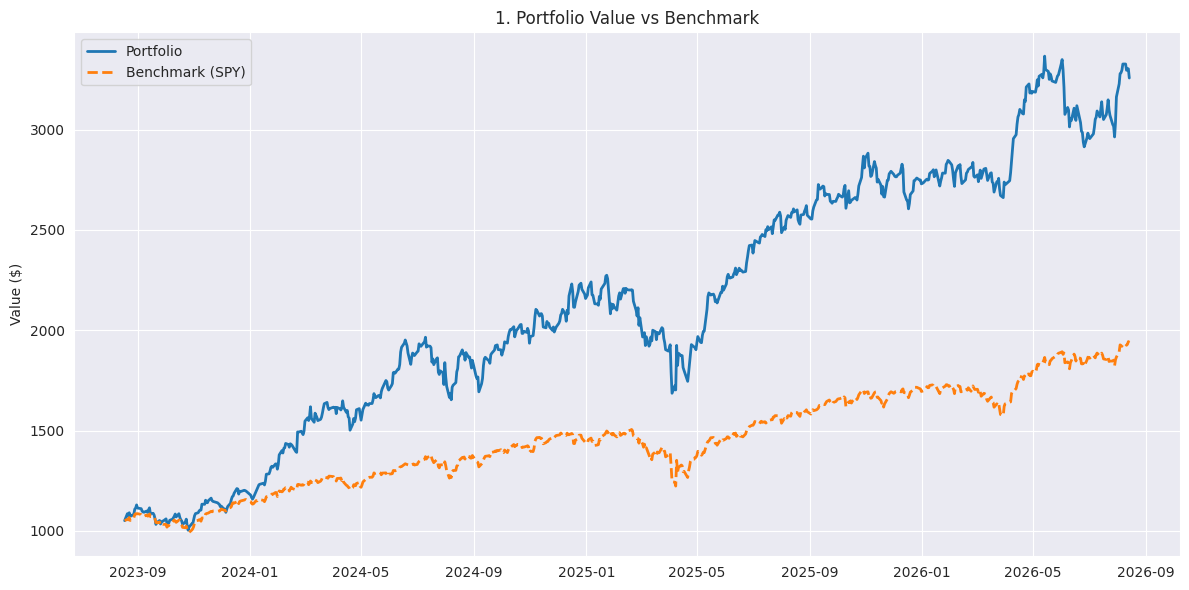

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(port_value.index, port_value, label="Portfolio", linewidth=2)
ax.plot(bench_value.index, bench_value, label="Benchmark (SPY)", linewidth=2, linestyle="--")
ax.set_title("1. Portfolio Value vs Benchmark"); ax.set_ylabel("Value ($)"); ax.legend()
plt.tight_layout(); plt.show()

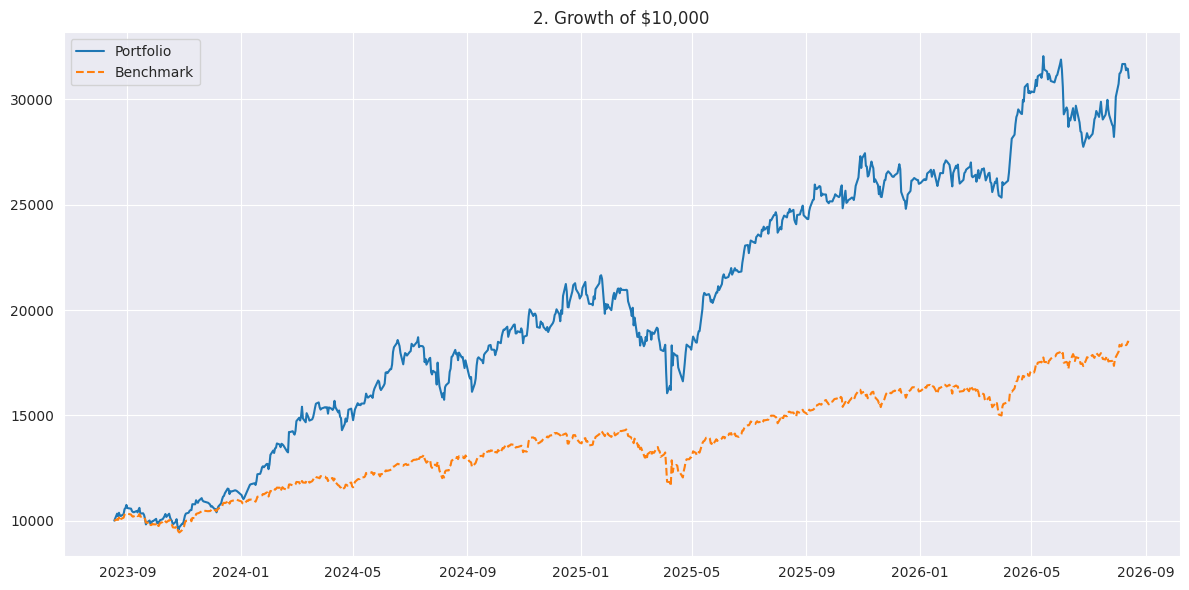

In [ ]:
port_growth = 10000 * port_cum
bench_growth = 10000 * bench_cum
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(port_growth.index, port_growth, label="Portfolio")
ax.plot(bench_growth.index, bench_growth, label="Benchmark", linestyle="--")
ax.set_title("2. Growth of $10,000"); ax.legend()
plt.tight_layout(); plt.show()

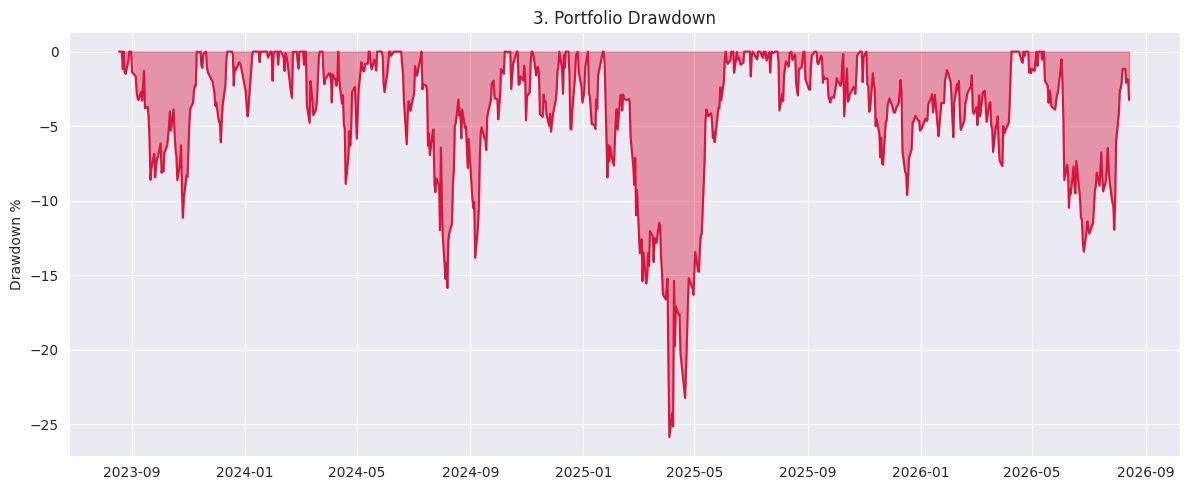

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(p_dd_series.index, p_dd_series * 100, 0, color="crimson", alpha=0.4)
ax.plot(p_dd_series.index, p_dd_series * 100, color="crimson")
ax.set_title("3. Portfolio Drawdown"); ax.set_ylabel("Drawdown %")
plt.tight_layout(); plt.show()

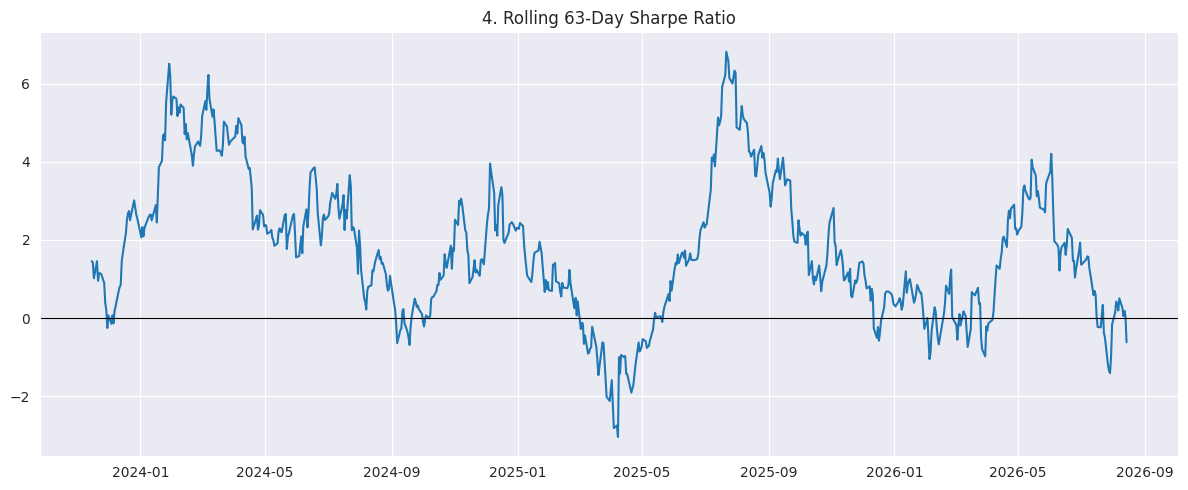

In [ ]:
window = 63
excess = port_returns - RISK_FREE_RATE / TRADING_DAYS
rolling_sharpe = (excess.rolling(window).mean() / port_returns.rolling(window).std()) * np.sqrt(TRADING_DAYS)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_sharpe.index, rolling_sharpe)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"4. Rolling {window}-Day Sharpe Ratio")
plt.tight_layout(); plt.show()

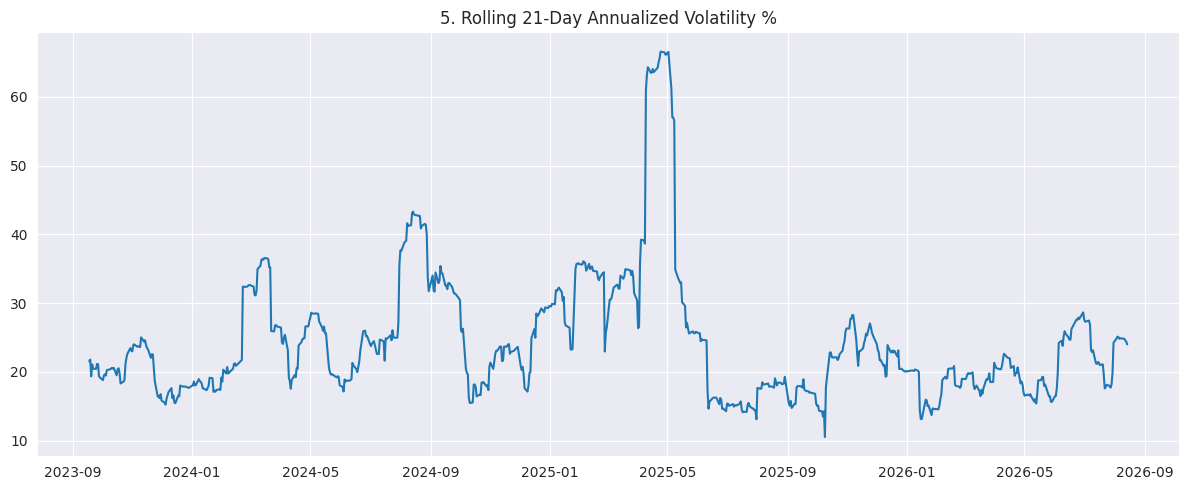

In [ ]:
window = 21
rolling_vol = port_returns.rolling(window).std() * np.sqrt(TRADING_DAYS)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_vol.index, rolling_vol * 100)
ax.set_title(f"5. Rolling {window}-Day Annualized Volatility %")
plt.tight_layout(); plt.show()

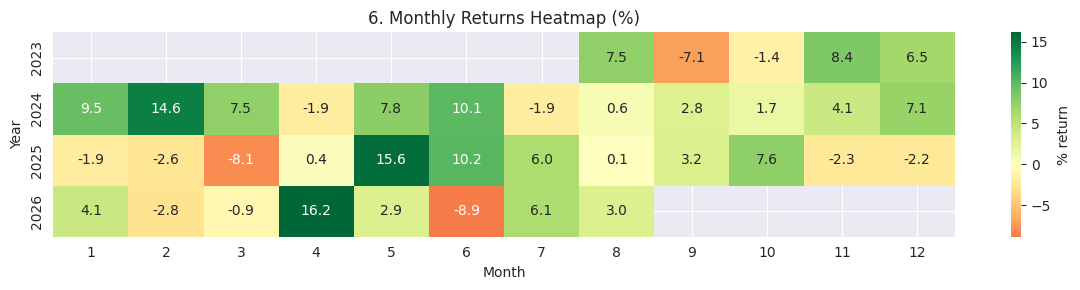

In [ ]:
monthly = p_month.to_frame("ret")
monthly["Year"], monthly["Month"] = monthly.index.year, monthly.index.month
pivot = monthly.pivot(index="Year", columns="Month", values="ret") * 100
fig, ax = plt.subplots(figsize=(12, max(3, 0.6 * pivot.shape[0])))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax, cbar_kws={"label": "% return"})
ax.set_title("6. Monthly Returns Heatmap (%)")
plt.tight_layout(); plt.show()

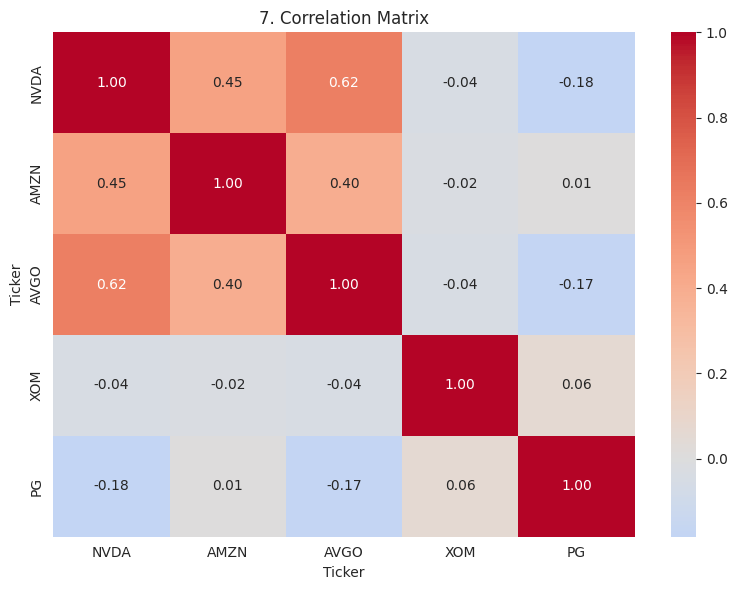

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("7. Correlation Matrix")
plt.tight_layout(); plt.show()

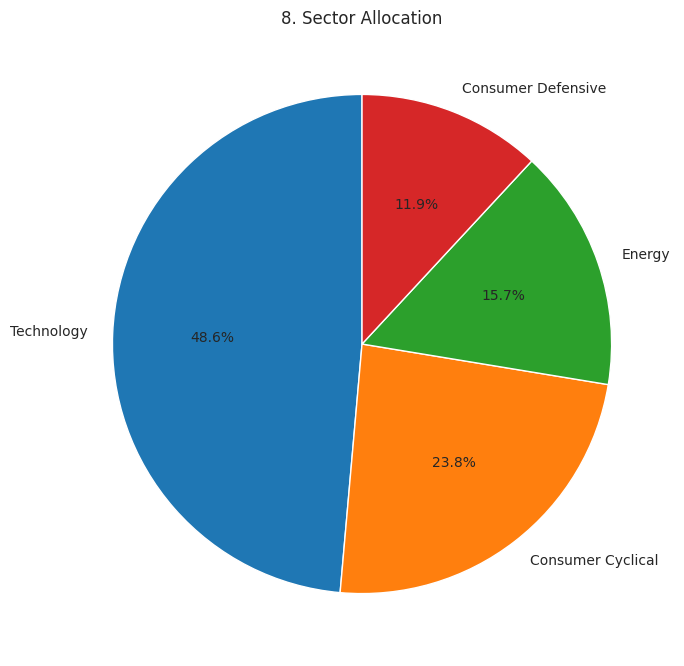

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sector_weights.values, labels=sector_weights.index, autopct="%1.1f%%", startangle=90)
ax.set_title("8. Sector Allocation")
plt.tight_layout(); plt.show()

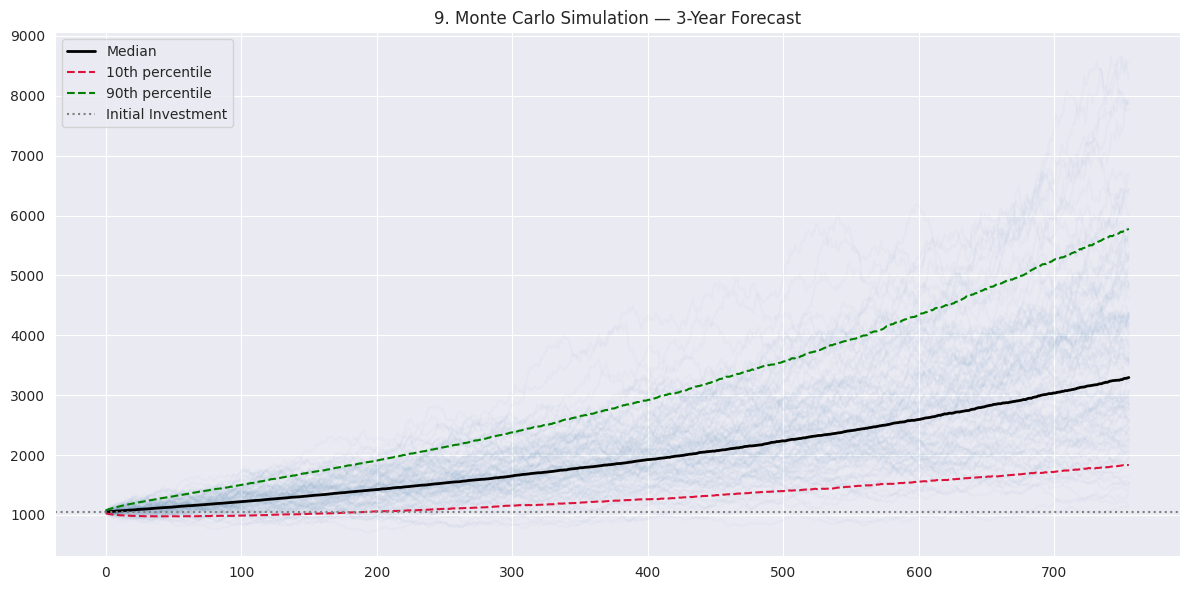

In [ ]:
years_to_plot = 3
res = mc_results[years_to_plot]
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(res["median_path"].shape[0])
for path in res["paths_sample"][:100]:
    ax.plot(x, path, color="steelblue", alpha=0.03)
ax.plot(x, res["median_path"], color="black", label="Median", linewidth=2)
ax.plot(x, res["p10_path"], color="crimson", linestyle="--", label="10th percentile")
ax.plot(x, res["p90_path"], color="green", linestyle="--", label="90th percentile")
ax.axhline(INITIAL_INVESTMENT, color="gray", linestyle=":", label="Initial Investment")
ax.set_title(f"9. Monte Carlo Simulation — {years_to_plot}-Year Forecast"); ax.legend()
plt.tight_layout(); plt.show()

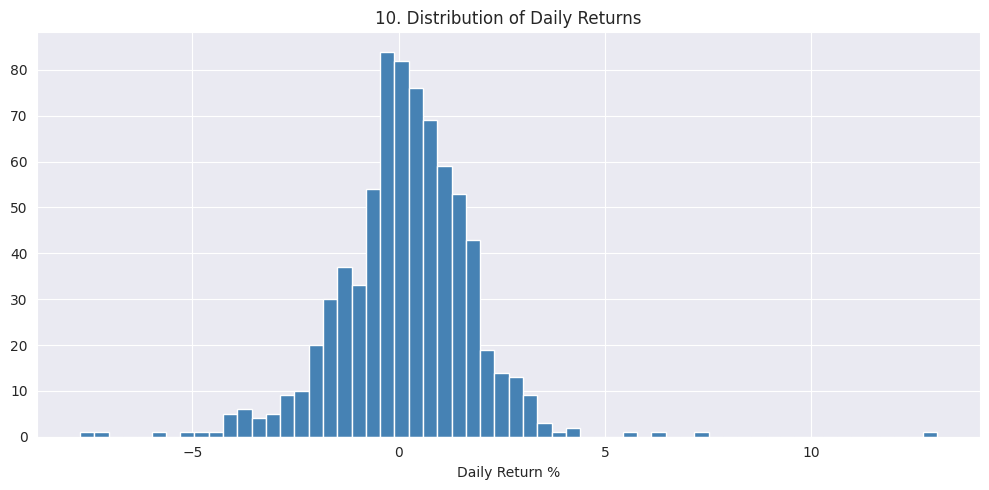

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(port_returns * 100, bins=60, color="steelblue", edgecolor="white")
ax.set_title("10. Distribution of Daily Returns"); ax.set_xlabel("Daily Return %")
plt.tight_layout(); plt.show()

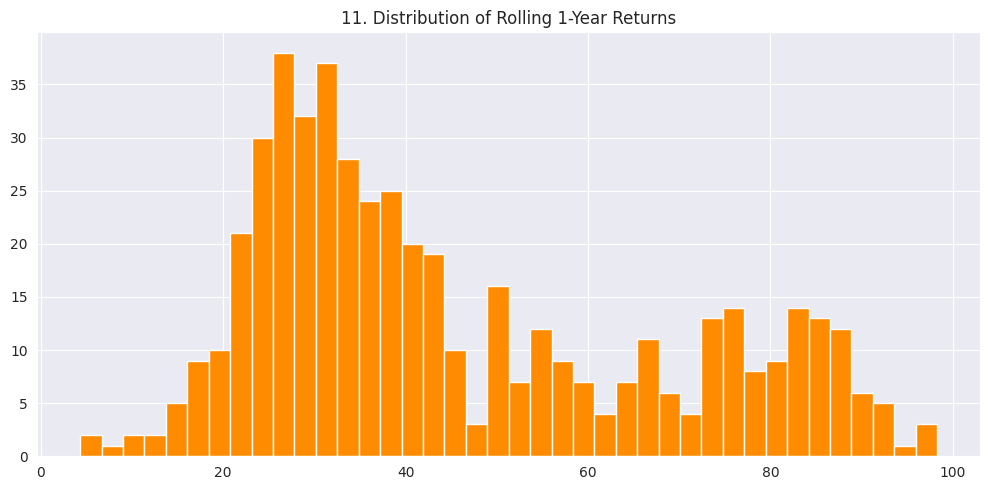

In [ ]:
rolling_ret = (1 + port_returns).rolling(TRADING_DAYS).apply(np.prod, raw=True) - 1
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rolling_ret.dropna() * 100, bins=40, color="darkorange", edgecolor="white")
ax.set_title("11. Distribution of Rolling 1-Year Returns")
plt.tight_layout(); plt.show()

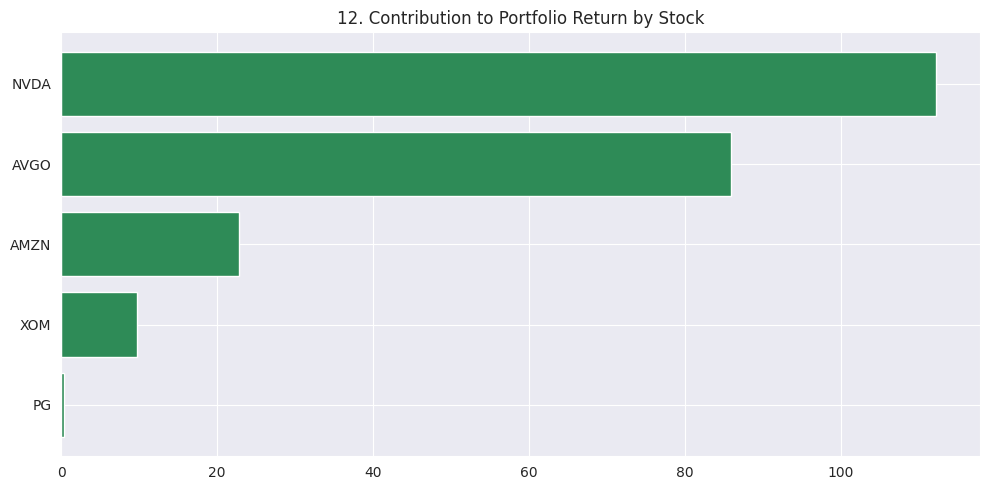

In [ ]:
sorted_df = stock_leaderboard.sort_values("Contribution to Portfolio %")
colors = ["crimson" if v < 0 else "seagreen" for v in sorted_df["Contribution to Portfolio %"]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sorted_df["Ticker"], sorted_df["Contribution to Portfolio %"], color=colors)
ax.set_title("12. Contribution to Portfolio Return by Stock")
plt.tight_layout(); plt.show()

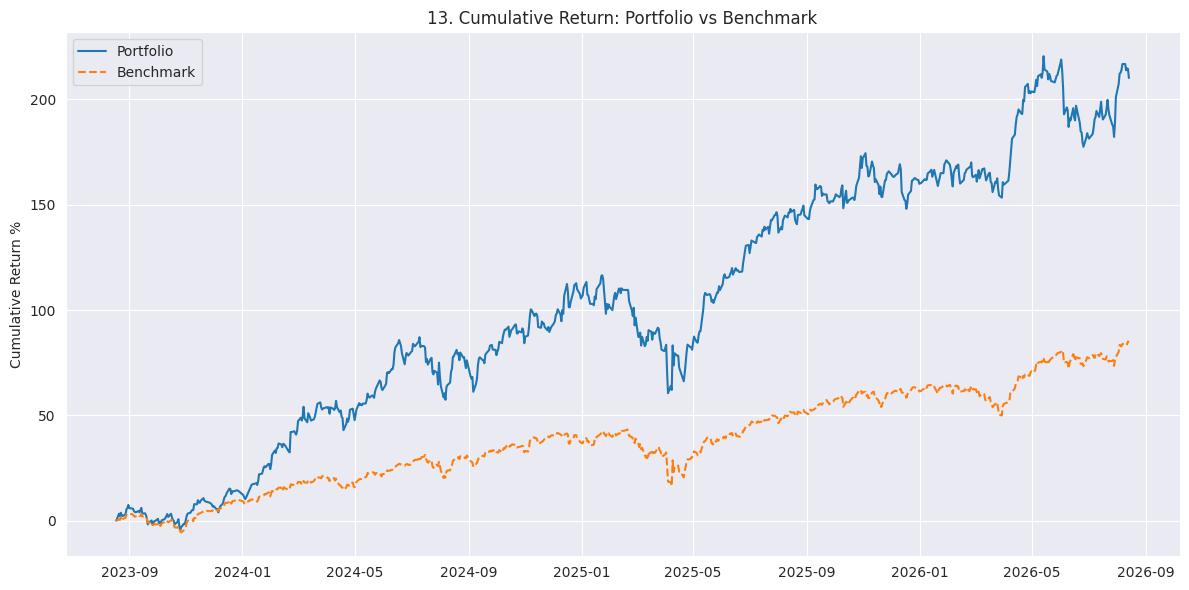

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(port_cum.index, (port_cum - 1) * 100, label="Portfolio")
ax.plot(bench_cum.index, (bench_cum - 1) * 100, label="Benchmark", linestyle="--")
ax.set_title("13. Cumulative Return: Portfolio vs Benchmark"); ax.set_ylabel("Cumulative Return %"); ax.legend()
plt.tight_layout(); plt.show()

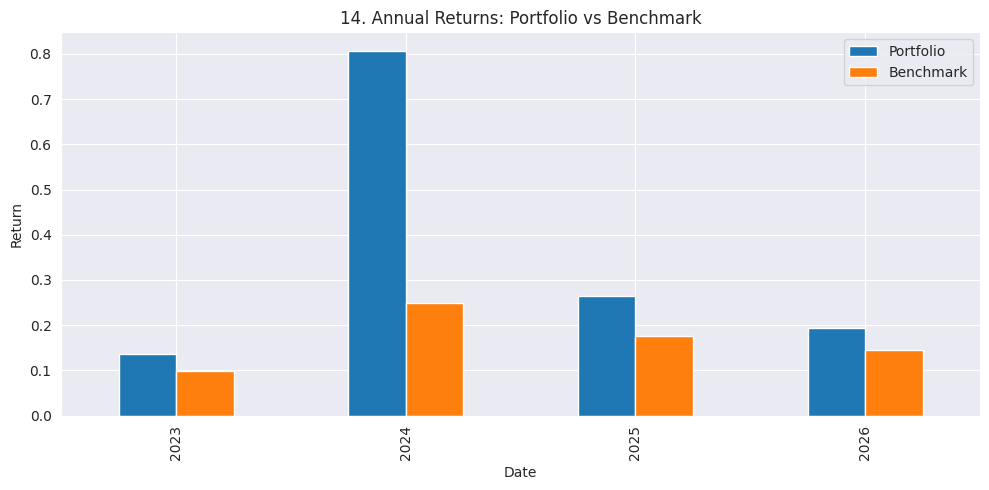

In [ ]:
p_annual = (1 + port_returns).resample('YE').prod() - 1
b_annual = (1 + bench_returns).resample('YE').prod() - 1
annual_df = pd.DataFrame({"Portfolio": p_annual.values, "Benchmark": b_annual.values}, index=p_annual.index.year)
fig, ax = plt.subplots(figsize=(10, 5))
annual_df.plot(kind="bar", ax=ax)
ax.set_title("14. Annual Returns: Portfolio vs Benchmark"); ax.set_ylabel("Return")
plt.tight_layout(); plt.show()

## Automatic Investment Report

In [ ]:
def investment_grade(sharpe, outperformance_pct):
    if sharpe >= 1.5 and outperformance_pct > 0:
        return "Excellent"
    elif sharpe >= 0.8:
        return "Good"
    elif sharpe >= 0.3:
        return "Average"
    else:
        return "Poor"

grade = investment_grade(p_sharpe, outperformance_pct)
best_stock = stock_leaderboard.iloc[0]
worst_stock = stock_leaderboard.iloc[-1]

report = f"""
==================================================
PORTFOLIO SUMMARY
==================================================
Tickers: {', '.join(TICKERS)}   |   Benchmark: {BENCHMARK}
Period: {START_DATE} to {END_DATE}   |   Initial Investment: ${INITIAL_INVESTMENT:,}
Weighting: {WEIGHTING_METHOD}   |   Rebalancing: {REBALANCE_FREQ}

STRENGTHS
- Best performer: {best_stock['Ticker']} ({best_stock['Total Return %']:.1f}% total return)
- Sharpe Ratio of {p_sharpe:.2f} indicates {'strong' if p_sharpe > 1 else 'moderate' if p_sharpe > 0.5 else 'weak'} risk-adjusted return
- {(p_month > 0).mean():.0%} of months were positive

WEAKNESSES
- Worst performer: {worst_stock['Ticker']} ({worst_stock['Total Return %']:.1f}% total return)
- Maximum drawdown of {p_mdd*100:.1f}% shows the portfolio's worst peak-to-trough loss
- Tracking error of {tracking_error*100:.1f}% vs benchmark

RISK ANALYSIS
- Annualized Volatility: {p_vol*100:.1f}%
- 95% Value at Risk (daily): {var95*100:.2f}%
- Beta vs {BENCHMARK}: {beta:.2f} ({'more' if beta > 1 else 'less'} volatile than the market)

DID THE PORTFOLIO BEAT THE MARKET?
{'YES' if port_cum.iloc[-1] > bench_cum.iloc[-1] else 'NO'} — outperformance of {outperformance_pct:+.2f} percentage points
Annualized Alpha: {alpha*100:+.2f}%

KEY TAKEAWAYS
1. This portfolio {'outperformed' if outperformance_pct > 0 else 'underperformed'} the S&P 500 over the test period on an absolute basis.
2. Risk-adjusted (Sharpe {p_sharpe:.2f} vs benchmark {b_sharpe:.2f}), it {'still comes out ahead' if p_sharpe > b_sharpe else 'lags the benchmark once volatility is accounted for'}.
3. Concentration risk is real with only 5 holdings — {sector_weights.index[0]} is the largest sector exposure at {sector_weights.iloc[0]:.0%}.

INVESTMENT GRADE: {grade}
==================================================
"""
print(report)



PORTFOLIO SUMMARY
Tickers: NVDA, AMZN, AVGO, XOM, PG   |   Benchmark: SPY
Period: 2023-08-17 to 2026-08-17   |   Initial Investment: $1,050
Weighting: Custom Weights   |   Rebalancing: Quarterly

STRENGTHS
- Best performer: NVDA (420.5% total return)
- Sharpe Ratio of 1.45 indicates strong risk-adjusted return
- 68% of months were positive

WEAKNESSES
- Worst performer: PG (2.8% total return)
- Maximum drawdown of -25.9% shows the portfolio's worst peak-to-trough loss
- Tracking error of 16.0% vs benchmark

RISK ANALYSIS
- Annualized Volatility: 25.9%
- 95% Value at Risk (daily): -2.48%
- Beta vs SPY: 1.37 (more volatile than the market)

DID THE PORTFOLIO BEAT THE MARKET?
YES — outperformance of +125.47 percentage points
Annualized Alpha: +11.49%

KEY TAKEAWAYS
1. This portfolio outperformed the S&P 500 over the test period on an absolute basis.
2. Risk-adjusted (Sharpe 1.45 vs benchmark 1.16), it still comes out ahead.
3. Concentration risk is real with only 5 holdings — Technology 

## Final Output

In [ ]:
final_summary = pd.DataFrame({
    "Metric": ["Initial Investment", "Final Portfolio Value", "Benchmark Final Value",
               "Total Return %", "CAGR %", "Sharpe Ratio", "Max Drawdown %",
               "Alpha (annualized) %", "Beta", "Outperformance %", "Investment Grade"],
    "Value": [f"${INITIAL_INVESTMENT:,.2f}", f"${port_value.iloc[-1]:,.2f}", f"${bench_value.iloc[-1]:,.2f}",
              f"{(port_cum.iloc[-1]-1)*100:.2f}%", f"{p_cagr*100:.2f}%", f"{p_sharpe:.2f}",
              f"{p_mdd*100:.2f}%", f"{alpha*100:.2f}%", f"{beta:.2f}", f"{outperformance_pct:+.2f}%", grade]
})
print(tabulate(final_summary, headers='keys', tablefmt='fancy_grid', showindex=False))


╒═══════════════════════╤═══════════╕
│ Metric                │ Value     │
╞═══════════════════════╪═══════════╡
│ Initial Investment    │ $1,050.00 │
├───────────────────────┼───────────┤
│ Final Portfolio Value │ $3,256.84 │
├───────────────────────┼───────────┤
│ Benchmark Final Value │ $1,939.37 │
├───────────────────────┼───────────┤
│ Total Return %        │ 210.18%   │
├───────────────────────┼───────────┤
│ CAGR %                │ 46.28%    │
├───────────────────────┼───────────┤
│ Sharpe Ratio          │ 1.45      │
├───────────────────────┼───────────┤
│ Max Drawdown %        │ -25.87%   │
├───────────────────────┼───────────┤
│ Alpha (annualized) %  │ 11.49%    │
├───────────────────────┼───────────┤
│ Beta                  │ 1.37      │
├───────────────────────┼───────────┤
│ Outperformance %      │ +125.47%  │
├───────────────────────┼───────────┤
│ Investment Grade      │ Good      │
╘═══════════════════════╧═══════════╛


## Testing an Alternate Allocation



I also tested a more aggressive version: 40% NVDA instead of my actual 26.7%, to see the trade-off.



- Alternate final value: $3,687.76 (vs. my actual $3,256.84)

- Alternate CAGR: 52.52% (vs. my actual 46.28%)

- Alternate Max Drawdown: -28.57% (vs. my actual -25.87%)



This showed me that going heavier into NVDA would have increased returns, but came with more risk a bigger max drawdown. I chose my actual 26.7% weighting instead because it balances upside with a level of risk I was comfortable with.

## Real Portfolio Check-In — [September 3th, 2026]
Two weeks after investing $1,050 into this allocation, my actual portfolio is worth about $1,067 (+1.6%). NVDA is up the most (+7.6%), matching what I expected going in, I weighted it heaviest because I saw it as the highest-upside, highest-risk pick. AVGO and AMZN are slightly down, which is normal short-term noise, not a sign my thesis was wrong. I'll keep tracking this over time.

## Real Portfolio Check-In — [September 20, 2026]
About 4 weeks after investing $1,050 into this allocation, my portfolio is worth
approximately $1,048, essentially flat (-0.17% overall). Performance is mixed across
holdings: NVDA is up 9.39%, matching my original thesis that it carried the highest
upside; PG is up slightly (+0.96%), acting as the defensive stabilizer I intended;
while AVGO (-5.20%), AMZN (-5.52%), and XOM (-1.70%) are down modestly. Short-term,
day-to-day swings (today alone was +$12.02) show the volatility I expected going in,
but the overall picture 4 weeks in is a portfolio holding roughly steady. I'll keep
tracking this over time.